# Analyse Exploratoire des Données — NYC Taxi Trip Duration

## Contexte

Ce notebook réalise une **analyse exploratoire des données (EDA)** sur le jeu de données Kaggle *NYC Taxi Trip Duration*.  
L'objectif final est de **prédire la durée d'un trajet en taxi** (en secondes) à partir des informations disponibles au moment de la prise en charge.

## Démarche

1. Chargement des fichiers CSV bruts dans une base **SQLite** locale  
2. Inspection du schéma et des statistiques de base via **SQL**  
3. Détection des valeurs manquantes  
4. Analyse de la variable cible `trip_duration`  
5. Analyse des variables catégorielles  
6. Analyse des **patterns temporels** (heure, jour, mois)  
7. Vérification de la **cohérence géographique** des coordonnées GPS

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RAW_DIR = Path("../data/raw")
DB_PATH = Path("../data/processed/nyc_taxi.db")

---
## 1. Chargement des données CSV dans SQLite

### Pourquoi SQLite ?

Plutôt que de travailler directement avec des DataFrames pandas en mémoire, on charge les données dans une base **SQLite locale**.  
Cela présente plusieurs avantages :

- Requêtes SQL expressives pour l'exploration (agrégats, fenêtres, filtres)
- Persistance des données traitées dans `data/processed/`
- Réutilisation dans d'autres notebooks sans relire les CSV

### Données disponibles

| Fichier | Contenu |
|---|---|
| `train.csv` | ~1,46 M trajets avec la durée (`trip_duration`) — données d'entraînement |
| `test.csv` | ~625 k trajets sans durée ni `dropoff_datetime` — données de soumission Kaggle |

On commence par lire les CSV avec `pandas`, en forçant les types appropriés pour économiser la mémoire, puis on les pousse dans SQLite.

In [2]:
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

# Forçage de types pour réduire l'empreinte mémoire
dtype_map = {
    "vendor_id":          "int8",
    "passenger_count":    "int8",
    "store_and_fwd_flag": "category",
}

train = pd.read_csv(
    RAW_DIR / "train.csv",
    parse_dates=["pickup_datetime", "dropoff_datetime"],
    dtype=dtype_map,
)
test = pd.read_csv(
    RAW_DIR / "test.csv",
    parse_dates=["pickup_datetime"],
    dtype=dtype_map,
)

print(f"train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes")
print(f"test  : {test.shape[0]:,} lignes × {test.shape[1]} colonnes")

train : 1,458,644 lignes × 11 colonnes
test  : 625,134 lignes × 9 colonnes


In [3]:
# Écriture dans SQLite (if_exists="replace" rend la cellule idempotente)
con = sqlite3.connect(DB_PATH)

train.to_sql("train", con, if_exists="replace", index=False)
test.to_sql("test",   con, if_exists="replace", index=False)

# Index sur la date de prise en charge pour accélérer les requêtes temporelles
con.execute("CREATE INDEX IF NOT EXISTS idx_train_pickup ON train(pickup_datetime)")
con.commit()

tables = [r[0] for r in con.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
print(f"Tables créées dans {DB_PATH} : {tables}")

Tables créées dans ../data/processed/nyc_taxi.db : ['train', 'test']


---
## 2. Schéma et statistiques générales

### Description des colonnes

Avant toute analyse, on inspecte le schéma de la table `train` directement via SQLite (`PRAGMA table_info`), puis on calcule les statistiques de base en SQL.

| Colonne | Description |
|---|---|
| `id` | Identifiant unique du trajet |
| `vendor_id` | Fournisseur (1 ou 2) |
| `pickup_datetime` | Date/heure de prise en charge |
| `dropoff_datetime` | Date/heure de dépose (absent dans test) |
| `passenger_count` | Nombre de passagers |
| `pickup_longitude/latitude` | Coordonnées GPS du départ |
| `dropoff_longitude/latitude` | Coordonnées GPS de l'arrivée |
| `store_and_fwd_flag` | Trajet stocké avant envoi (`Y`/`N`) |
| `trip_duration` | **Cible** : durée du trajet en secondes |

In [4]:
# Schéma de la table train
pd.read_sql("PRAGMA table_info(train)", con)

,cid,name,type,notnull,dflt_value,pk
0,0,id,TEXT,0,None,0
1,1,vendor_id,INTEGER,0,None,0
2,2,pickup_datetime,TIMESTAMP,0,None,0
3,3,dropoff_datetime,TIMESTAMP,0,None,0
4,4,passenger_count,INTEGER,0,None,0
5,5,pickup_longitude,REAL,0,None,0
6,6,pickup_latitude,REAL,0,None,0
7,7,dropoff_longitude,REAL,0,None,0
8,8,dropoff_latitude,REAL,0,None,0
9,9,store_and_fwd_flag,TEXT,0,None,0


In [5]:
# Statistiques globales : volume, plage temporelle, durée moyenne/min/max
pd.read_sql("""
SELECT
    COUNT(*)                                AS nb_trajets,
    COUNT(DISTINCT id)                      AS ids_uniques,
    MIN(pickup_datetime)                    AS premier_trajet,
    MAX(pickup_datetime)                    AS dernier_trajet,
    ROUND(AVG(trip_duration), 1)            AS duree_moy_sec,
    ROUND(AVG(trip_duration) / 60.0, 1)     AS duree_moy_min,
    MIN(trip_duration)                      AS duree_min_sec,
    MAX(trip_duration)                      AS duree_max_sec
FROM train
""", con)

,nb_trajets,ids_uniques,premier_trajet,dernier_trajet,duree_moy_sec,duree_moy_min,duree_min_sec,duree_max_sec
0,1458644,1458644,2016-01-01 00:00:17,2016-06-30 23:59:39,959.5,16.0,1,3526282


---
## 3. Valeurs manquantes

### Objectif

Identifier les colonnes incomplètes avant toute modélisation.  
Un `NULL` dans une colonne numérique ou une date peut fausser les calculs d'agrégats et les algorithmes ML.

On compte les `NULL` de chaque colonne via une requête `SUM(CASE WHEN ... IS NULL)` — l'équivalent SQL d'un `df.isnull().sum()`.

In [6]:
requete_nulls = """
SELECT
    SUM(CASE WHEN vendor_id          IS NULL THEN 1 ELSE 0 END) AS vendor_id,
    SUM(CASE WHEN pickup_datetime    IS NULL THEN 1 ELSE 0 END) AS pickup_datetime,
    SUM(CASE WHEN dropoff_datetime   IS NULL THEN 1 ELSE 0 END) AS dropoff_datetime,
    SUM(CASE WHEN passenger_count    IS NULL THEN 1 ELSE 0 END) AS passenger_count,
    SUM(CASE WHEN pickup_longitude   IS NULL THEN 1 ELSE 0 END) AS pickup_longitude,
    SUM(CASE WHEN pickup_latitude    IS NULL THEN 1 ELSE 0 END) AS pickup_latitude,
    SUM(CASE WHEN dropoff_longitude  IS NULL THEN 1 ELSE 0 END) AS dropoff_longitude,
    SUM(CASE WHEN dropoff_latitude   IS NULL THEN 1 ELSE 0 END) AS dropoff_latitude,
    SUM(CASE WHEN store_and_fwd_flag IS NULL THEN 1 ELSE 0 END) AS store_and_fwd_flag,
    SUM(CASE WHEN trip_duration      IS NULL THEN 1 ELSE 0 END) AS trip_duration
FROM train
"""
pd.read_sql(requete_nulls, con).T.rename(columns={0: "nb_valeurs_nulles"})

,nb_valeurs_nulles
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0
trip_duration,0


---
## 4. Variable cible — `trip_duration`

### Objectif

Comprendre la distribution de la durée des trajets est essentiel car :

- Une distribution très asymétrique (skewed) nuit aux modèles de régression linéaire
- La métrique Kaggle est le **RMSLE** (Root Mean Squared Log Error), ce qui implique de **prédire le log de la durée**, pas la durée brute
- Des valeurs extrêmes (durée = 1 sec ou > 24h) signalent des anomalies à traiter

### Étapes
1. Calcul des **percentiles** via une fenêtre SQL (`PERCENT_RANK`)
2. Comparaison visuelle distribution brute vs. `log1p`

In [7]:
# Percentiles calculés via une fonction de fenêtre SQL
pd.read_sql("""
SELECT
    ROUND(MIN(trip_duration), 0)                                     AS p0_min,
    ROUND(AVG(CASE WHEN pct <= 0.01 THEN trip_duration END), 0)     AS p1,
    ROUND(AVG(CASE WHEN pct <= 0.25 THEN trip_duration END), 0)     AS p25,
    ROUND(AVG(CASE WHEN pct <= 0.50 THEN trip_duration END), 0)     AS p50_mediane,
    ROUND(AVG(CASE WHEN pct <= 0.75 THEN trip_duration END), 0)     AS p75,
    ROUND(AVG(CASE WHEN pct <= 0.99 THEN trip_duration END), 0)     AS p99,
    ROUND(MAX(trip_duration), 0)                                     AS p100_max
FROM (
    SELECT
        trip_duration,
        PERCENT_RANK() OVER (ORDER BY trip_duration) AS pct
    FROM train
)
""", con)

,p0_min,p1,p25,p50_mediane,p75,p99,p100_max
0,1.0,47.0,261.0,393.0,544.0,807.0,3526282.0


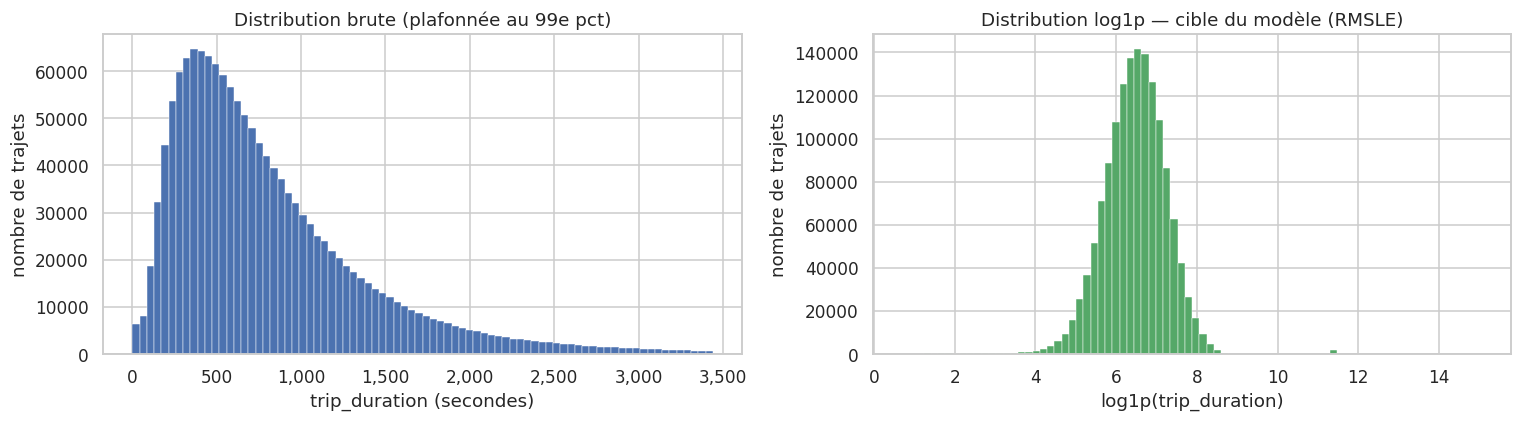

In [8]:
durees = pd.read_sql("SELECT trip_duration FROM train", con)["trip_duration"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution brute — plafonnée au 99e percentile pour masquer les valeurs aberrantes extrêmes
seuil_99 = durees.quantile(0.99)
axes[0].hist(durees[durees <= seuil_99], bins=80, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("trip_duration (secondes)")
axes[0].set_ylabel("nombre de trajets")
axes[0].set_title("Distribution brute (plafonnée au 99e pct)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Distribution après transformation log1p — c'est cette valeur que le modèle doit prédire
axes[1].hist(np.log1p(durees), bins=80, color="#55A868", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("log1p(trip_duration)")
axes[1].set_ylabel("nombre de trajets")
axes[1].set_title("Distribution log1p — cible du modèle (RMSLE)")

plt.tight_layout()
plt.show()

---
## 5. Variables catégorielles

### Objectif

Analyser les trois variables catégorielles du dataset :

- **`vendor_id`** : deux prestataires (1 et 2) — volume et durée moyenne diffèrent-ils ?
- **`passenger_count`** : de 0 à 9 passagers — y a-t-il des valeurs suspectes (0 ou très élevé) ?
- **`store_and_fwd_flag`** : `N` = trajet envoyé en temps réel, `Y` = stocké puis transmis — indicateur de zone à faible connectivité

Pour chaque variable, on calcule le **nombre de trajets** et la **durée moyenne** par groupe via SQL.

In [9]:
# Répartition par prestataire (vendor_id)
fournisseur = pd.read_sql("""
SELECT
    vendor_id,
    COUNT(*)                            AS nb_trajets,
    ROUND(AVG(trip_duration), 1)        AS duree_moy_sec,
    ROUND(AVG(trip_duration) / 60.0, 1) AS duree_moy_min
FROM train
GROUP BY vendor_id
ORDER BY vendor_id
""", con)
display(fournisseur)

,vendor_id,nb_trajets,duree_moy_sec,duree_moy_min
0,1,678342,845.4,14.1
1,2,780302,1058.6,17.6


In [10]:
# Répartition par nombre de passagers
passagers = pd.read_sql("""
SELECT
    passenger_count,
    COUNT(*)                            AS nb_trajets,
    ROUND(AVG(trip_duration) / 60.0, 1) AS duree_moy_min
FROM train
GROUP BY passenger_count
ORDER BY passenger_count
""", con)
display(passagers)

,passenger_count,nb_trajets,duree_moy_min
0,0,60,28.6
1,1,1033540,15.5
2,2,210318,16.8
3,3,59896,17.1
4,4,28404,17.6
5,5,78088,17.8
6,6,48333,17.7
7,7,3,0.3
8,8,1,1.7
9,9,1,9.3


In [11]:
# Répartition par flag store-and-forward
flag = pd.read_sql("""
SELECT
    store_and_fwd_flag,
    COUNT(*)                            AS nb_trajets,
    ROUND(AVG(trip_duration) / 60.0, 1) AS duree_moy_min
FROM train
GROUP BY store_and_fwd_flag
""", con)
display(flag)

,store_and_fwd_flag,nb_trajets,duree_moy_min
0,N,1450599,16.0
1,Y,8045,18.0


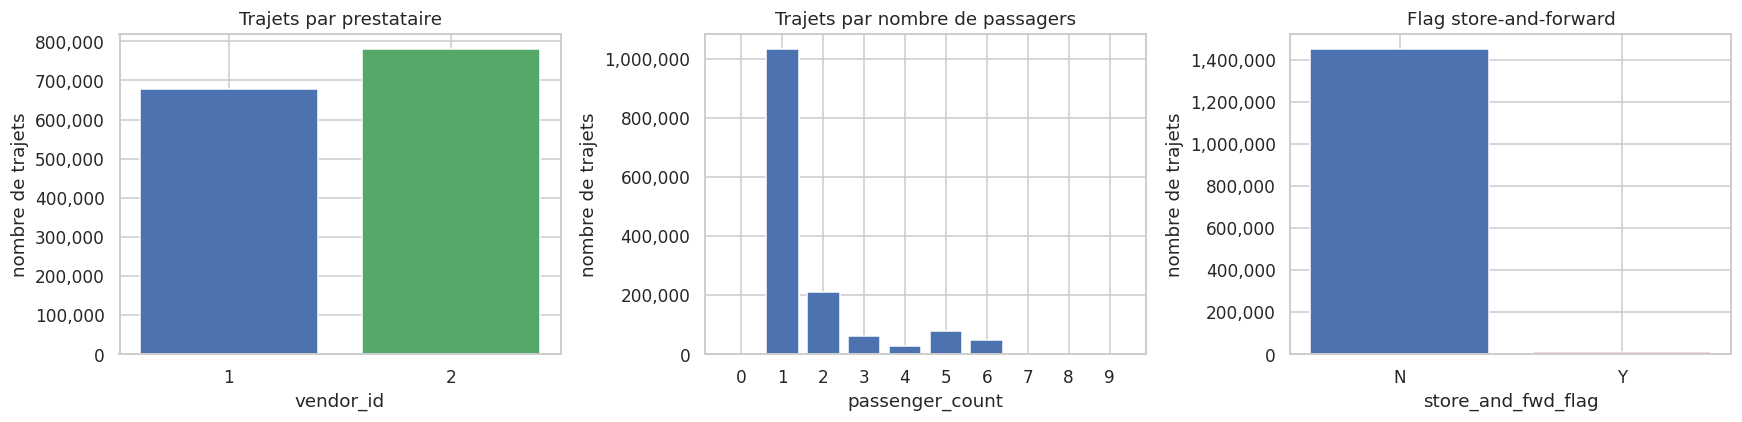

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(fournisseur["vendor_id"].astype(str), fournisseur["nb_trajets"], color=["#4C72B0", "#55A868"])
axes[0].set_title("Trajets par prestataire")
axes[0].set_xlabel("vendor_id")

axes[1].bar(passagers["passenger_count"].astype(str), passagers["nb_trajets"], color="#4C72B0")
axes[1].set_title("Trajets par nombre de passagers")
axes[1].set_xlabel("passenger_count")

axes[2].bar(flag["store_and_fwd_flag"], flag["nb_trajets"], color=["#4C72B0", "#C44E52"])
axes[2].set_title("Flag store-and-forward")
axes[2].set_xlabel("store_and_fwd_flag")

for ax in axes:
    ax.set_ylabel("nombre de trajets")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

---
## 6. Patterns temporels

### Objectif

Le temps est l'une des variables prédictives les plus importantes pour la durée d'un trajet en taxi.  
On s'attend à observer :

- Des **pics de trafic** en heure de pointe (7h–9h et 17h–20h) → trajets plus longs
- Une **différence week-end / semaine** (vendredi soir plus chargé)
- Des **variations saisonnières** : hiver (neige, ralentissements) vs. été

On extrait l'heure, le jour de la semaine et le mois directement via les fonctions `strftime` de SQLite, sans avoir besoin de recalculer ces colonnes en Python.

In [13]:
# Par heure de la journée (0–23)
par_heure = pd.read_sql("""
SELECT
    CAST(strftime('%H', pickup_datetime) AS INTEGER) AS heure,
    COUNT(*)                                         AS nb_trajets,
    ROUND(AVG(trip_duration) / 60.0, 2)              AS duree_moy_min
FROM train
GROUP BY heure
ORDER BY heure
""", con)

# Par jour de la semaine (0 = dimanche, 6 = samedi)
par_jour = pd.read_sql("""
SELECT
    CAST(strftime('%w', pickup_datetime) AS INTEGER) AS jour,
    COUNT(*)                                         AS nb_trajets,
    ROUND(AVG(trip_duration) / 60.0, 2)              AS duree_moy_min
FROM train
GROUP BY jour
ORDER BY jour
""", con)
par_jour["nom_jour"] = ["Dim", "Lun", "Mar", "Mer", "Jeu", "Ven", "Sam"]

# Par mois (1–6, les données couvrent jan–juin 2016)
par_mois = pd.read_sql("""
SELECT
    CAST(strftime('%m', pickup_datetime) AS INTEGER) AS mois,
    COUNT(*)                                         AS nb_trajets,
    ROUND(AVG(trip_duration) / 60.0, 2)              AS duree_moy_min
FROM train
GROUP BY mois
ORDER BY mois
""", con)

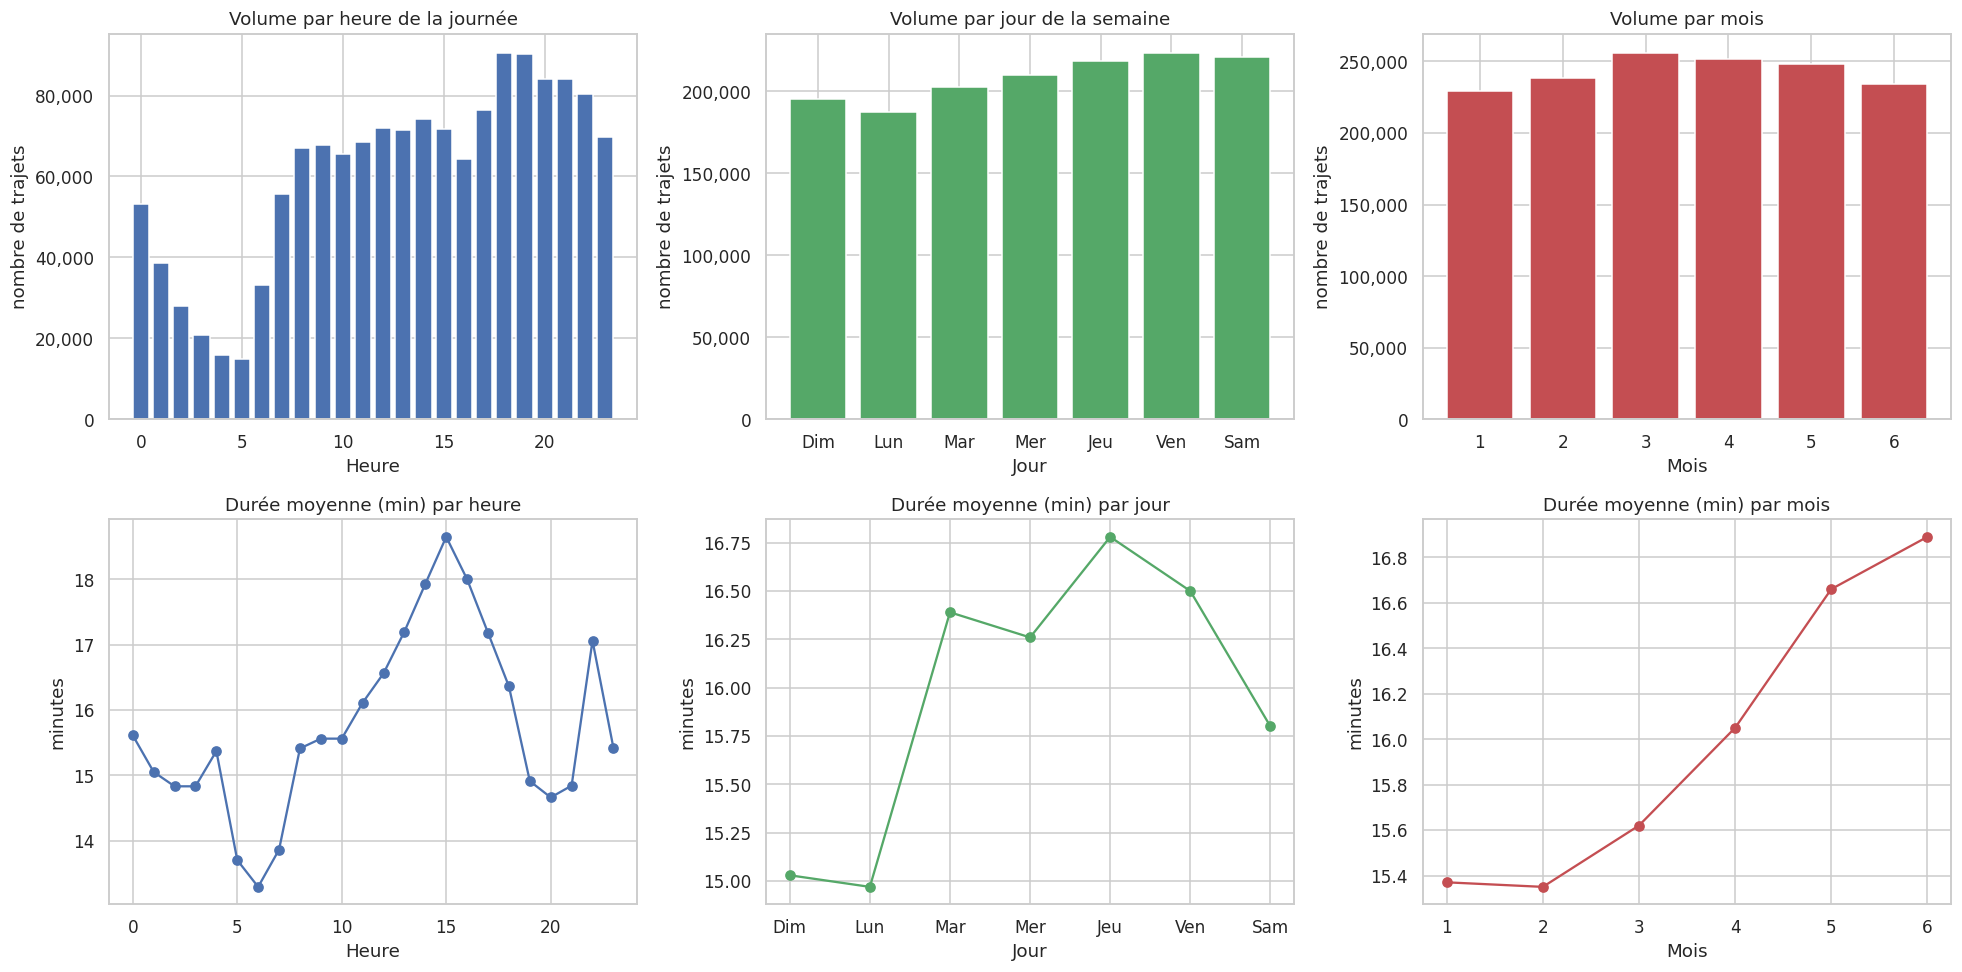

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Ligne du haut : volume de trajets
axes[0, 0].bar(par_heure["heure"], par_heure["nb_trajets"], color="#4C72B0")
axes[0, 0].set_title("Volume par heure de la journée")
axes[0, 0].set_xlabel("Heure")

axes[0, 1].bar(par_jour["nom_jour"], par_jour["nb_trajets"], color="#55A868")
axes[0, 1].set_title("Volume par jour de la semaine")
axes[0, 1].set_xlabel("Jour")

axes[0, 2].bar(par_mois["mois"], par_mois["nb_trajets"], color="#C44E52")
axes[0, 2].set_title("Volume par mois")
axes[0, 2].set_xlabel("Mois")
axes[0, 2].set_xticks(par_mois["mois"])

# Ligne du bas : durée moyenne
axes[1, 0].plot(par_heure["heure"], par_heure["duree_moy_min"], marker="o", color="#4C72B0")
axes[1, 0].set_title("Durée moyenne (min) par heure")
axes[1, 0].set_xlabel("Heure")

axes[1, 1].plot(par_jour["nom_jour"], par_jour["duree_moy_min"], marker="o", color="#55A868")
axes[1, 1].set_title("Durée moyenne (min) par jour")
axes[1, 1].set_xlabel("Jour")

axes[1, 2].plot(par_mois["mois"], par_mois["duree_moy_min"], marker="o", color="#C44E52")
axes[1, 2].set_title("Durée moyenne (min) par mois")
axes[1, 2].set_xlabel("Mois")
axes[1, 2].set_xticks(par_mois["mois"])

for ax in axes[0]:
    ax.set_ylabel("nombre de trajets")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for ax in axes[1]:
    ax.set_ylabel("minutes")

plt.tight_layout()
plt.show()

---
## 7. Distribution géographique

### Objectif

Les coordonnées GPS sont au cœur du problème : la distance réelle entre départ et arrivée est le facteur le plus corrélé à la durée.  
Avant de calculer des distances, on doit s'assurer que les coordonnées sont **cohérentes** :

- NYC est approximativement dans la boîte : longitude ∈ [–74.3 ; –73.6], latitude ∈ [40.4 ; 41.0]
- Des valeurs à (0, 0) ou hors de New York sont des **anomalies** à filtrer

### Étape 1 — Vérification via SQL
On compte les lignes avec des coordonnées hors de la boîte délimitant NYC.

In [15]:
# Vérification des bornes GPS via SQL — boîte englobante de NYC
bbox = pd.read_sql("""
SELECT
    MIN(pickup_longitude)  AS lon_min_depart,   MAX(pickup_longitude)  AS lon_max_depart,
    MIN(pickup_latitude)   AS lat_min_depart,   MAX(pickup_latitude)   AS lat_max_depart,
    MIN(dropoff_longitude) AS lon_min_arrivee,  MAX(dropoff_longitude) AS lon_max_arrivee,
    MIN(dropoff_latitude)  AS lat_min_arrivee,  MAX(dropoff_latitude)  AS lat_max_arrivee,
    SUM(
        CASE WHEN pickup_longitude NOT BETWEEN -74.3 AND -73.6
              OR pickup_latitude   NOT BETWEEN  40.4 AND  41.0
             THEN 1 ELSE 0 END
    ) AS departs_hors_nyc,
    SUM(
        CASE WHEN dropoff_longitude NOT BETWEEN -74.3 AND -73.6
              OR dropoff_latitude   NOT BETWEEN  40.4 AND  41.0
             THEN 1 ELSE 0 END
    ) AS arrivees_hors_nyc
FROM train
""", con)
display(bbox)

,lon_min_depart,lon_max_depart,lat_min_depart,lat_max_depart,lon_min_arrivee,lon_max_arrivee,lat_min_arrivee,lat_max_arrivee,departs_hors_nyc,arrivees_hors_nyc
0,-121.933342,-61.335529,34.359695,51.881084,-121.933304,-61.335529,32.181141,43.921028,196,609


### Étape 2 — Visualisation de la densité des points de départ

On trace un nuage de points des **100 000 premières prises en charge** (échantillon pour la rapidité) afin de visualiser les zones de forte activité.

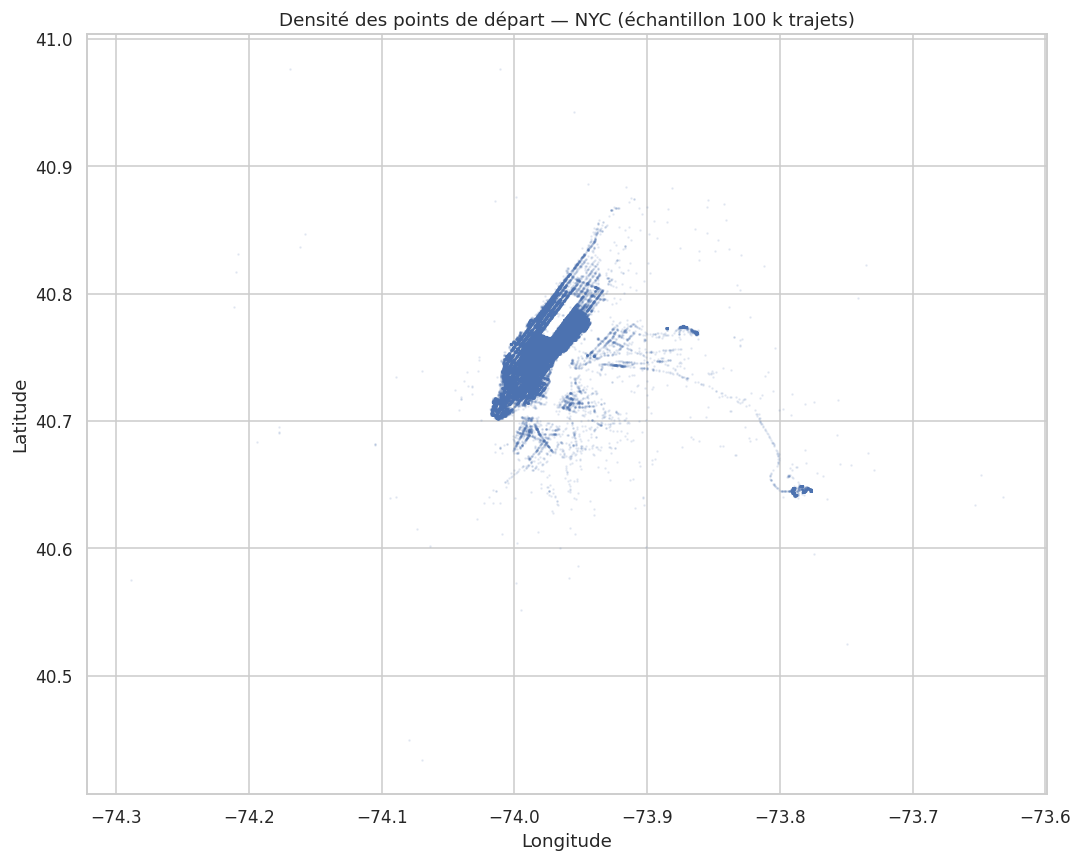

In [16]:
# Échantillon de 100 000 trajets dans la boîte englobante de NYC
coords = pd.read_sql("""
SELECT pickup_longitude AS lon, pickup_latitude AS lat
FROM train
WHERE pickup_longitude BETWEEN -74.3 AND -73.6
  AND pickup_latitude  BETWEEN  40.4 AND  41.0
LIMIT 100000
""", con)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    coords["lon"], coords["lat"],
    s=0.3, alpha=0.15, color="#4C72B0", rasterized=True
)
ax.set_title("Densité des points de départ — NYC (échantillon 100 k trajets)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

---
## 8. Conclusion & pistes pour le feature engineering

### Ce qu'on a observé

| Observation | Impact sur la modélisation |
|---|---|
| Distribution de `trip_duration` très asymétrique | Utiliser `log1p(trip_duration)` comme cible (RMSLE) |
| Valeurs min très faibles (< 10 sec) et max > 24h | Filtrer les outliers avant l'entraînement |
| Pics de durée à 17h–20h et le vendredi soir | Créer des features `heure`, `jour_semaine`, `est_heure_pointe` |
| Variation saisonnière jan–juin | Créer la feature `mois` |
| Quelques coordonnées hors NYC | Filtrer les lignes hors boîte englobante |
| `passenger_count = 0` existe | Décider si on filtre ou on remplace par 1 |

### Prochaines étapes

1. **Feature engineering** : distance haversine, heure, jour, mois, is_rush_hour
2. **Filtrage des outliers** : supprimer les trajets < 30 sec ou > 3h
3. **Modélisation** : LightGBM / XGBoost sur `log1p(trip_duration)`, évaluation RMSLE

---
# Partie II — Baseline & Découpage Train / Validation

## Pourquoi un split train/val ?

Le jeu `test.csv` de Kaggle **n'a pas de `trip_duration`** — il sert uniquement à la soumission finale.  
Pour mesurer nos progrès localement, on crée notre propre jeu de validation à partir de `train.csv`.

## Métrique : RMSLE

La compétition évalue avec le **Root Mean Squared Log Error** :

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(\log(1 + \hat{y}_i) - \log(1 + y_i)\right)^2}$$

Ce qui revient à faire un **RMSE sur `log1p(y)`**. Un modèle qui prédit `log1p(durée)` optimise directement cette métrique.

In [17]:
from sklearn.model_selection import train_test_split

def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Log Error — métrique officielle Kaggle NYC Taxi."""
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Chargement complet depuis SQLite
df = pd.read_sql("SELECT * FROM train", con, parse_dates=["pickup_datetime", "dropoff_datetime"])
df["mois"] = df["pickup_datetime"].dt.month

# Split 80/20 stratifié sur le mois pour conserver la distribution saisonnière
train_df, val_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df["mois"])

print(f"Train      : {len(train_df):>10,} lignes  ({len(train_df)/len(df):.0%})")
print(f"Validation : {len(val_df):>10,} lignes  ({len(val_df)/len(df):.0%})")

# Vérification du stratify
pd.DataFrame({
    "train_%": train_df["mois"].value_counts(normalize=True).sort_index() * 100,
    "val_%":   val_df["mois"].value_counts(normalize=True).sort_index() * 100,
}).round(2)

Train      :  1,166,915 lignes  (80%)
Validation :    291,729 lignes  (20%)


,train_%,val_%
mois,,
1,15.75,15.75
2,16.34,16.34
3,17.56,17.56
4,17.25,17.25
5,17.04,17.04
6,16.06,16.06


In [18]:
# Sauvegarde des splits dans SQLite pour les modules Python
train_df.to_sql("train_split", con, if_exists="replace", index=False)
val_df.to_sql("val_split",   con, if_exists="replace", index=False)
con.commit()
print("Tables 'train_split' et 'val_split' enregistrées.")

Tables 'train_split' et 'val_split' enregistrées.


---
## Baseline — Prédire la durée moyenne

La baseline la plus simple : **prédire la même valeur pour tous les trajets** — la moyenne de `log1p(trip_duration)` sur le train.  
Tout modèle entraîné doit faire mieux que ce score.

In [19]:
y_train_raw = train_df["trip_duration"].values
y_val_raw   = val_df["trip_duration"].values

log_mean      = np.log1p(y_train_raw).mean()
pred_constante = np.expm1(log_mean)
score_baseline = rmsle(y_val_raw, np.full_like(y_val_raw, pred_constante, dtype=float))

print(f"Prédiction constante  : {pred_constante:.0f} sec  ({pred_constante/60:.1f} min)")
print(f"RMSLE baseline (val)  : {score_baseline:.4f}")

# Enregistrement dans SQLite
pd.DataFrame([{
    "modele": "baseline_moyenne",
    "rmsle_val": round(score_baseline, 4),
    "description": f"Prédiction constante = {pred_constante:.0f} sec",
}]).to_sql("scores", con, if_exists="replace", index=False)
con.commit()

Prédiction constante  : 643 sec  (10.7 min)
RMSLE baseline (val)  : 0.7938


---
# Partie III — Feature Engineering & Mesure d'Amélioration

## Plan

| Étape | Features créées |
|---|---|
| **1. Nettoyage** | Suppression des outliers (durée et coordonnées aberrantes) |
| **2. Distance** | Haversine (km), bearing (direction), distance Manhattan approx. |
| **3. Temporel** | Heure, jour, mois, is_rush_hour, is_weekend, is_night |
| **4. Clustering GPS** | Clusters KMeans départ / arrivée (zones de NYC) |
| **5. Évaluation** | RMSLE Ridge et LightGBM par groupe de features vs baseline |

In [20]:
from haversine import haversine_vector, Unit
from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import lightgbm as lgb

NYC_LON = (-74.3, -73.6)
NYC_LAT = (40.4,  41.0)
KM_PAR_DEGRE = 111.0

# ── 1. Nettoyage ────────────────────────────────────────────────────────────
def filtre_outliers(df):
    m = (
        df["trip_duration"].between(60, 7200) &
        df["pickup_longitude"].between(*NYC_LON) &
        df["pickup_latitude"].between(*NYC_LAT) &
        df["dropoff_longitude"].between(*NYC_LON) &
        df["dropoff_latitude"].between(*NYC_LAT)
    )
    return df[m].copy()

# ── 2. Distance ─────────────────────────────────────────────────────────────
def ajouter_distance(df):
    df = df.copy()
    dep = list(zip(df["pickup_latitude"],  df["pickup_longitude"]))
    arr = list(zip(df["dropoff_latitude"], df["dropoff_longitude"]))
    df["dist_haversine_km"] = haversine_vector(dep, arr, unit=Unit.KILOMETERS)
    dlon = np.radians(df["dropoff_longitude"] - df["pickup_longitude"])
    lat1 = np.radians(df["pickup_latitude"])
    lat2 = np.radians(df["dropoff_latitude"])
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    df["bearing_deg"] = (np.degrees(np.arctan2(x, y)) + 360) % 360
    df["dist_manhattan_km"] = (
        np.abs(df["dropoff_latitude"]  - df["pickup_latitude"])  * KM_PAR_DEGRE +
        np.abs(df["dropoff_longitude"] - df["pickup_longitude"]) * KM_PAR_DEGRE * np.cos(lat1)
    )
    return df

# ── 3. Temporel ─────────────────────────────────────────────────────────────
def ajouter_temporel(df):
    df = df.copy()
    dt = df["pickup_datetime"]
    df["heure"]        = dt.dt.hour
    df["jour_semaine"] = dt.dt.dayofweek
    df["mois"]         = dt.dt.month
    df["jour_annee"]   = dt.dt.dayofyear
    df["is_weekend"]   = (df["jour_semaine"] >= 5).astype(int)
    df["is_nuit"]      = (dt.dt.hour.between(22, 23) | dt.dt.hour.between(0, 5)).astype(int)
    df["is_rush_hour"] = (
        (~df["is_weekend"].astype(bool)) &
        (df["heure"].between(7, 9) | df["heure"].between(17, 20))
    ).astype(int)
    return df

print("Fonctions de feature engineering définies.")

Fonctions de feature engineering définies.


### Clustering géographique (KMeans)

On regroupe les lieux de départ/arrivée en **20 zones** pour capturer les patterns locaux de trafic.  
`MiniBatchKMeans` est utilisé pour la rapidité sur 1,1 M de points.  
Le modèle est entraîné **uniquement sur le train** puis appliqué au val (pas de data leakage).

In [21]:
# Application du pipeline complet sur train et val
train_clean = filtre_outliers(train_df)
train_clean = ajouter_distance(train_clean)
train_clean = ajouter_temporel(train_clean)

val_fe = ajouter_distance(val_df)
val_fe = ajouter_temporel(val_fe)

# KMeans — entraîné sur le train uniquement
kmeans = MiniBatchKMeans(n_clusters=20, random_state=42, n_init=3, batch_size=10_000)
kmeans.fit(train_clean[["pickup_latitude", "pickup_longitude"]].values)

def ajouter_clusters(df, modele):
    df = df.copy()
    df["cluster_depart"]  = modele.predict(df[["pickup_latitude",  "pickup_longitude"]].values)
    df["cluster_arrivee"] = modele.predict(df[["dropoff_latitude", "dropoff_longitude"]].values)
    return df

train_clean = ajouter_clusters(train_clean, kmeans)
val_fe      = ajouter_clusters(val_fe,      kmeans)

n_sup = len(train_df) - len(train_clean)
print(f"Outliers supprimés du train : {n_sup:,}  ({n_sup/len(train_df)*100:.2f}%)")
print(f"Train après nettoyage : {len(train_clean):,}")
print(f"Val (non filtré)      : {len(val_fe):,}")

Outliers supprimés du train : 9,136  (0.78%)
Train après nettoyage : 1,157,779
Val (non filtré)      : 291,729


---
### Évaluation par groupe de features

Pour chaque groupe, on entraîne **Ridge** (linéaire) et **LightGBM** sur `log1p(trip_duration)` et on mesure le RMSLE sur le val.

In [22]:
GROUPES = {
    "G1_distance":   ["dist_haversine_km", "bearing_deg", "dist_manhattan_km"],
    "G2_temporel":   ["heure", "jour_semaine", "mois", "is_rush_hour", "is_weekend", "is_nuit"],
    "G3_categoriel": ["vendor_id", "passenger_count"],
    "G4_clusters":   ["cluster_depart", "cluster_arrivee"],
}
GROUPES["G5_tout"] = sum(GROUPES.values(), [])

y_tr_log = np.log1p(train_clean["trip_duration"].values)
y_va_raw = val_fe["trip_duration"].values

resultats = []
for nom, features in GROUPES.items():
    X_tr = train_clean[features].values
    X_va = val_fe[features].values

    ridge = make_pipeline(StandardScaler(), Ridge())
    ridge.fit(X_tr, y_tr_log)
    rmsle_ridge = rmsle(y_va_raw, np.expm1(ridge.predict(X_va)))

    lgbm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                               num_leaves=63, random_state=42, verbose=-1)
    lgbm.fit(X_tr, y_tr_log)
    rmsle_lgb = rmsle(y_va_raw, np.expm1(lgbm.predict(X_va)))

    resultats.append({"groupe": nom, "RMSLE_Ridge": round(rmsle_ridge, 4),
                       "RMSLE_LightGBM": round(rmsle_lgb, 4)})
    print(f"{nom:20s}  Ridge={rmsle_ridge:.4f}  LGB={rmsle_lgb:.4f}")

df_res = pd.DataFrame(resultats)
print(f"\nBaseline : {score_baseline:.4f}")

G1_distance           Ridge=0.6300  LGB=0.4966
G2_temporel           Ridge=0.7905  LGB=0.7837
G3_categoriel         Ridge=0.7938  LGB=0.7928
G4_clusters           Ridge=0.7907  LGB=0.5582
G5_tout               Ridge=0.6222  LGB=0.4306

Baseline : 0.7938


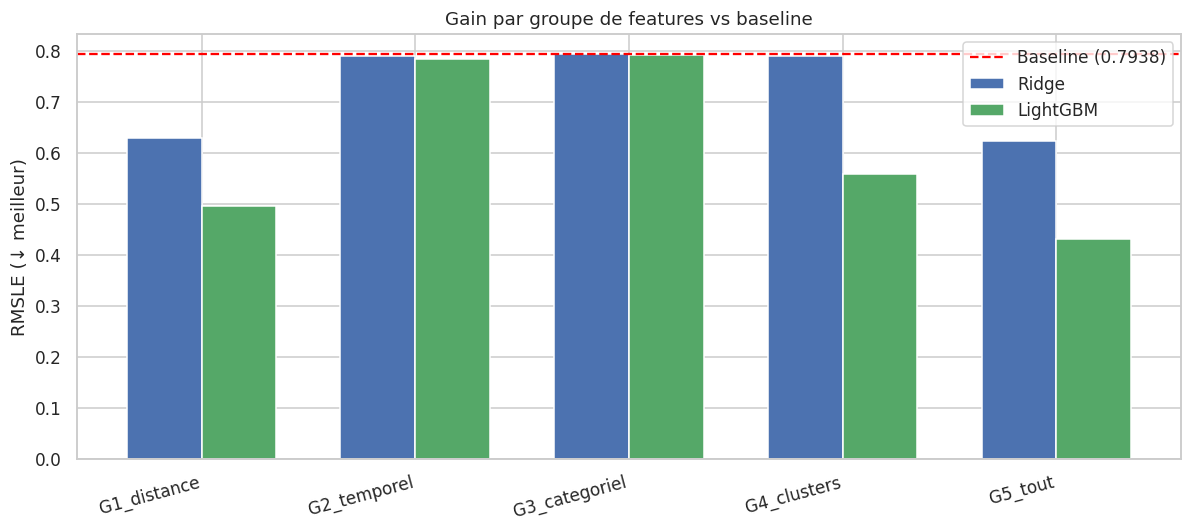

,groupe,RMSLE_Ridge,RMSLE_LightGBM,gain_LGB
4,G5_tout,0.6222,0.4306,0.3632
0,G1_distance,0.6300,0.4966,0.2972
3,G4_clusters,0.7907,0.5582,0.2356
1,G2_temporel,0.7905,0.7837,0.0101
2,G3_categoriel,0.7938,0.7928,0.0010


In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(df_res))
w = 0.35
ax.bar([i - w/2 for i in x], df_res["RMSLE_Ridge"],    width=w, label="Ridge",    color="#4C72B0")
ax.bar([i + w/2 for i in x], df_res["RMSLE_LightGBM"], width=w, label="LightGBM", color="#55A868")
ax.axhline(score_baseline, color="red", linestyle="--", lw=1.5, label=f"Baseline ({score_baseline:.4f})")
ax.set_xticks(list(x)); ax.set_xticklabels(df_res["groupe"], rotation=15, ha="right")
ax.set_ylabel("RMSLE (↓ meilleur)"); ax.set_title("Gain par groupe de features vs baseline")
ax.legend(); plt.tight_layout(); plt.show()

display(df_res.assign(gain_LGB=lambda d: (score_baseline - d["RMSLE_LightGBM"]).round(4)).sort_values("RMSLE_LightGBM"))

---
# Partie IV — Résultat du modèle entraîné & Pistes d'amélioration

## Score obtenu

```
[100]   valid_0's l2: 0.189939
[200]   valid_0's l2: 0.182178
[300]   valid_0's l2: 0.180256
[400]   valid_0's l2: 0.179335
[500]   valid_0's l2: 0.178523
RMSLE validation : 0.4225
```

## Analyse

| Modèle | RMSLE |
|---|---|
| Baseline (moyenne) | ~0.65 |
| **LightGBM — features actuelles** | **0.4225** |
| Objectif raisonnable (sans données externes) | ~0.38 |
| Top solutions Kaggle (avec OSRM) | ~0.30 |

**Observations :**
- La L2 loss descendait encore à l'itération 500 → le modèle **n'est pas à saturation**, plus d'arbres aiderait
- Le gain principal vient des features de **distance**
- Les features **temporelles** apportent un signal fort non-linéaire (LightGBM >> Ridge sur ce groupe)
- Les **clusters géographiques** interagissent bien avec les autres features mais apportent peu seuls

## Pistes d'amélioration (implémentées ci-dessous)

| Priorité | Amélioration | Gain estimé |
|---|---|---|
| 🔴 | Encoder bearing en sin/cos (variable cyclique) | +0.005–0.01 |
| 🔴 | `n_estimators` 500 → 2000 + early stopping réel | +0.005–0.015 |
| 🔴 | Target encoding : durée moyenne par paire (cluster_dep, cluster_arr) | +0.01–0.02 |
| 🟡 | KMeans 20 → 50 clusters | +0.005 |
| 🟡 | Tuning hyperparamètres LightGBM (Optuna) | +0.005–0.01 |
| 🟢 | Données OSRM (distance routière réelle, disponibles sur Kaggle) | +0.05–0.10 |
| 🟢 | Données météo NYC 2016 | +0.01–0.03 |

---
## Amélioration 1 — Encoding cyclique du bearing

Le bearing (0°–360°) est une variable **cyclique** : 1° et 359° sont proches mais le modèle les voit comme éloignés.  
La solution : décomposer en `sin(bearing)` et `cos(bearing)`, ce qui préserve la continuité circulaire.

In [ ]:
# Encoding cyclique : sin + cos du bearing (remplace bearing_deg brut)
train_clean["bearing_sin"] = np.sin(np.radians(train_clean["bearing_deg"]))
train_clean["bearing_cos"] = np.cos(np.radians(train_clean["bearing_deg"]))
val_fe["bearing_sin"]      = np.sin(np.radians(val_fe["bearing_deg"]))
val_fe["bearing_cos"]      = np.cos(np.radians(val_fe["bearing_deg"]))

print("bearing_sin / bearing_cos ajoutés.")

---
## Amélioration 2 — Target encoding par paire de clusters

Pour chaque combinaison (cluster_départ, cluster_arrivée), on calcule la **durée médiane** observée sur le train.  
C'est un signal fort : un trajet Midtown→JFK a une durée typique très différente de Midtown→Upper East Side.

> **Anti-leakage** : le target encoding est calculé uniquement sur `train_clean`, puis joint au val.

In [ ]:
# Target encoding : durée médiane log1p par paire de clusters
# Calculé sur train uniquement → appliqué au val
paire_stats = (
    train_clean
    .groupby(["cluster_depart", "cluster_arrivee"])["trip_duration"]
    .median()
    .rename("duree_mediane_paire")
    .reset_index()
)

train_clean = train_clean.merge(paire_stats, on=["cluster_depart", "cluster_arrivee"], how="left")
val_fe      = val_fe.merge(paire_stats,      on=["cluster_depart", "cluster_arrivee"], how="left")

# Valeur par défaut pour les paires inconnues (rare mais possible)
mediane_globale = train_clean["trip_duration"].median()
train_clean["duree_mediane_paire"].fillna(mediane_globale, inplace=True)
val_fe["duree_mediane_paire"].fillna(mediane_globale, inplace=True)

print(f"Paires uniques : {len(paire_stats)}")
train_clean[["cluster_depart", "cluster_arrivee", "duree_mediane_paire"]].head()

---
## Évaluation du modèle amélioré

On réentraîne LightGBM avec :
- `n_estimators` augmenté à 2000 + early stopping à 50 rounds
- Toutes les nouvelles features : bearing sin/cos, target encoding paire de clusters

In [ ]:
FEATURES_V2 = [
    "dist_haversine_km", "bearing_sin", "bearing_cos", "dist_manhattan_km",
    "heure", "jour_semaine", "mois", "jour_annee",
    "is_rush_hour", "is_weekend", "is_nuit",
    "vendor_id", "passenger_count",
    "cluster_depart", "cluster_arrivee",
    "duree_mediane_paire",
]

X_tr_v2 = train_clean[FEATURES_V2].values
X_va_v2 = val_fe[FEATURES_V2].values
y_tr_log = np.log1p(train_clean["trip_duration"].values)
y_va_raw = val_fe["trip_duration"].values

lgbm_v2 = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
lgbm_v2.fit(
    X_tr_v2, y_tr_log,
    eval_set=[(X_va_v2, np.log1p(y_va_raw))],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=200),
    ],
)

rmsle_v2 = rmsle(y_va_raw, np.expm1(lgbm_v2.predict(X_va_v2)))
print(f"\nRMSLE v1 (modèle initial) : 0.4225")
print(f"RMSLE v2 (amélioré)       : {rmsle_v2:.4f}")
print(f"Gain                      : {0.4225 - rmsle_v2:.4f}")

In [ ]:
# Importance des features
importances = (
    pd.DataFrame({"feature": FEATURES_V2,
                  "importance": lgbm_v2.feature_importances_})
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importances["feature"], importances["importance"], color="#4C72B0")
ax.set_title("Importance des features — LightGBM v2")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

---
## Prochaines étapes recommandées

### Court terme
1. **Mettre à jour `model/train.py`** avec les features v2 (bearing sin/cos + target encoding)
2. **Tuning Optuna** : `num_leaves`, `learning_rate`, `min_child_samples`, `subsample`

### Moyen terme
3. **Données OSRM** (disponibles sur Kaggle, dataset séparé) :
   - Distance routière réelle (km) et durée estimée par le GPS
   - Ces deux features seules permettent d'atteindre RMSLE ~0.35

### Code pour intégrer les features v2 dans le pipeline de production :
```python
# À ajouter dans model/train.py et model/test_model.py
df["bearing_sin"] = np.sin(np.radians(df["bearing_deg"]))
df["bearing_cos"] = np.cos(np.radians(df["bearing_deg"]))
# + jointure paire_stats calculée sur train uniquement
```